# **Project 4: Gaussian Processes and Kernel Methods**
Taha Akhlaq & Kenneth Chan

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv

# For Stretch Goal
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import load_breast_cancer

np.random.seed(388)

In [ ]:
# Gaussian Kernel Function (Eq. 6.23 in tb)
def Gaussian_kernel(X1, X2, sigma=0.1):

    differences = np.subtract.outer(X1, X2) # Squared differences between X1 and X2
    squared_distances = differences ** 2
    kernel_matrix = np.exp(-0.5 * squared_distances / sigma**2)

    return kernel_matrix

# Gaussian Prediction (Eq. 6.66 and 6.67 in tb)
def Gauss_predict(x_training_data, t_training_data, x_test_data, beta, sigma):
    # Kernel matrix
    K = Gaussian_kernel(x_training_data, x_training_data, sigma)
    C = K + (1 / beta) * np.eye(len(x_training_data))
    C_inverse = inv(C)
    # Computes kernel between training and test points
    K_test = Gaussian_kernel(x_training_data, x_test_data, sigma)
    K_test_transpose = K_test.T
    c = np.ones(len(x_test_data)) + (1 / beta) # c is a scalar

    # Computes predictive mean: m(x*) = kᵗ C⁻¹ t from tb
    mean = K_test_transpose @ C_inverse @ t_training_data

    # Computes predictive variance: σ²(x*) = c - kᵗ C⁻¹ k from tb
    k_Cinv_k = np.sum(K_test_transpose @ C_inverse * K_test_transpose, axis=1)
    variance = c - k_Cinv_k
    variance = np.maximum(variance, 0)
    std = np.sqrt(variance)

    return mean, std

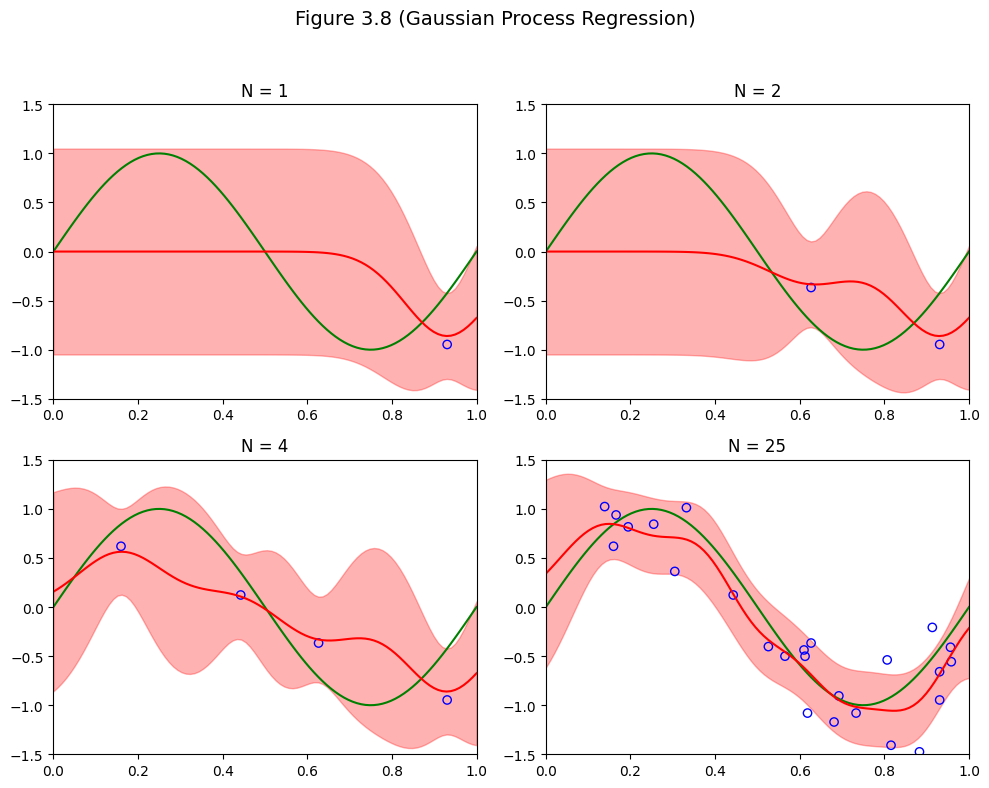

In [ ]:
# Plotting

# Parameters
beta = 10
sigma = 0.1
x_test_data = np.linspace(0, 1, 100)
true_func = np.sin(2 * np.pi * x_test_data)

full_x_training_data = np.random.rand(25)
full_t_training_data = np.sin(2 * np.pi * full_x_training_data) + np.random.normal(0, np.sqrt(1 / beta), 25)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle("Figure 3.8 (Gaussian Process Regression)", fontsize=14)

for i, N in enumerate([1, 2, 4, 25]):
    # Select N training samples
    x_training_data = full_x_training_data[:N]
    t_training_data = full_t_training_data[:N]

    # Get mean and standard deviation
    mean, std = Gauss_predict(x_training_data, t_training_data, x_test_data, beta, sigma)

    ax = axes[i // 2, i % 2]
    ax.plot(x_test_data, true_func, 'g', label='True Function')
    ax.plot(x_test_data, mean, 'r', label='GP Mean')
    ax.fill_between(x_test_data, mean - std, mean + std, color='red', alpha=0.3)
    ax.scatter(x_training_data, t_training_data, facecolors='none', edgecolors='b')
    ax.set_title(f"N = {N}")
    ax.set_xlim(0, 1)
    ax.set_ylim(-1.5, 1.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

SVM on Project 3
Accuracy: 92.50%


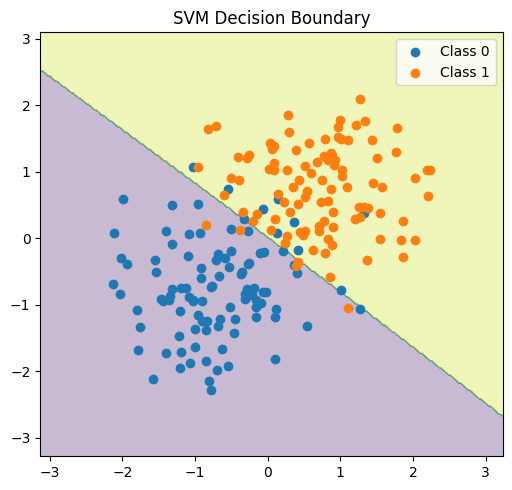


SVM on Breast Cancer Data 
Accuracy: 91.21%


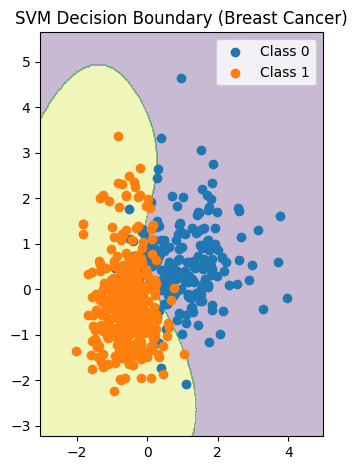

In [ ]:
# Stretch Goal

# From Project 3
N = 100
Mu1 = np.array([1, 1])
Mu2 = np.array([-1, -1])
Sigma = np.eye(2)

data_1 = np.random.multivariate_normal(Mu1, Sigma, N)
data_2 = np.random.multivariate_normal(Mu2, Sigma, N)

X = np.vstack([data_1, data_2])
Y = np.hstack([np.ones(N), np.zeros(N)])

# Scales Data
scale = StandardScaler()
X_scaled = scale.fit_transform(X)

# Grid Search
param_grid = {
    'C': [2 ** i for i in range(-5, 15, 2)], # Numbers are based on page 5 of paper
    'gamma': [2 ** i for i in range(-15, 3, 2)]
}

svm = SVC(kernel='rbf')
grid = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_scaled, Y)

print("SVM on Project 3")
best_svm = grid.best_estimator_
accuracy = 100 * best_svm.score(X_scaled, Y)
print(f"Accuracy: {accuracy:.2f}%")

# Plotting
xx, yy = np.meshgrid(np.linspace(X_scaled[:, 0].min()-1, X_scaled[:, 0].max()+1, 300),
                     np.linspace(X_scaled[:, 1].min()-1, X_scaled[:, 1].max()+1, 300))
Z = best_svm.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_scaled[Y == 0, 0], X_scaled[Y == 0, 1], label="Class 0")
plt.scatter(X_scaled[Y == 1, 0], X_scaled[Y == 1, 1], label="Class 1")
plt.title("SVM Decision Boundary")
plt.legend()
plt.tight_layout()
plt.show()

# Breast Cancer Dataset
# bc for breast cancer
dataset = load_breast_cancer()
X_bc = dataset.data[:, :2]  # only use first 2 features
Y_bc = dataset.target

# Scale Data
scale_bc = StandardScaler()
X_bc_scaled = scale_bc.fit_transform(X_bc)

# Grid Search
svm_bc = SVC(kernel='rbf')
grid_bc = GridSearchCV(svm_bc, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_bc.fit(X_bc_scaled, Y_bc)

print("\nSVM on Breast Cancer Data ")
best_svm_bc = grid_bc.best_estimator_
accuracy_bc = 100 * best_svm_bc.score(X_bc_scaled, Y_bc)
print(f"Accuracy: {accuracy_bc:.2f}%")

# Plot Decision Boundary
xx_bc, yy_bc = np.meshgrid(np.linspace(X_bc_scaled[:, 0].min()-1, X_bc_scaled[:, 0].max()+1, 300),
                           np.linspace(X_bc_scaled[:, 1].min()-1, X_bc_scaled[:, 1].max()+1, 300))
Z_bc = best_svm_bc.predict(np.c_[xx_bc.ravel(), yy_bc.ravel()]).reshape(xx_bc.shape)

plt.subplot(1, 2, 2)
plt.contourf(xx_bc, yy_bc, Z_bc, alpha=0.3)
plt.scatter(X_bc_scaled[Y_bc == 0, 0], X_bc_scaled[Y_bc == 0, 1], label="Class 0")
plt.scatter(X_bc_scaled[Y_bc == 1, 0], X_bc_scaled[Y_bc == 1, 1], label="Class 1")
plt.title("SVM Decision Boundary (Breast Cancer)")
plt.legend()

plt.tight_layout()
plt.show()